<a href="https://colab.research.google.com/github/CarisR/CarisR/blob/main/IoT_Sensor_Imputation_Benchmarking_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Data-Centric Imputation Comparison for IoT Sensor Data
#
# Research Question: Which data imputation strategy produces
# the best predictions on sparse IoT sensor data?
#
# Dataset: IoT-Based Energy and Environmental Parameters
#          in a Smart Building Infrastructure
# Source: github.com/adel8641/Dataset-of-IoT-Based-Energy-and-Environmental-Parameters-in-a-Smart-Building-Infrastructure
#
# Team: Derrick, Lawrence, Caris

# Install fancyimpute for SoftImpute
!pip install fancyimpute -q

# Import everything we need
import os
import glob
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from fancyimpute import SoftImpute
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.0 MB/s eta 0:00:00


In [ ]:
# Step 1: Clone the dataset and load all 53 CSV files
# The dataset is from a smart building with IoT sensors
# tracking energy usage, temperature, humidity, and occupancy
# across multiple devices and rooms

repo_url = "https://github.com/adel8641/Dataset-of-IoT-Based-Energy-and-Environmental-Parameters-in-a-Smart-Building-Infrastructure.git"
repo_name = repo_url.split('/')[-1].replace('.git', '')
local_path = os.path.join("/content", repo_name)

# Clone
!git clone {repo_url} {local_path}
print("Dataset cloned successfully.")

# Find all CSV files in the repo
csv_files = glob.glob(os.path.join(local_path, "**", "*.csv"), recursive=True)
print(f"Found {len(csv_files)} CSV files.")

Cloning into '/content/Dataset-of-IoT-Based-Energy-and-Environmental-Parameters-in-a-Smart-Building-Infrastructure'...
remote: Enumerating objects: 330, done.
remote: Counting objects: 100% (262/262), done.
remote: Compressing objects: 100% (157/157), done.
remote: Total 330 (delta 161), reused 188 (delta 104), pack-reused 68 (from 1)
Receiving objects: 100% (330/330), 344.86 KiB | 7.84 MiB/s, done.
Resolving deltas: 100% (210/210), done.
Dataset cloned successfully.
Found 53 CSV files.


In [ ]:
# Step 2: Reshape the data correctly
# Each CSV file is one sensor type for one device
# (e.g., Fridge watts, Kitchen humidity, Printer amps)
# We need to merge them by timestamp so each row has
# all sensor readings at that point in time

merged = None

for file in sorted(csv_files):
    temp = pd.read_csv(file)
    name = os.path.basename(file)

    # Get the value column (everything thats not 'time')
    value_col = [c for c in temp.columns if c != 'time'][0]

    # Extract device name from filename
    parts = name.replace('.csv', '').split(' Data ')
    device = parts[-1] if len(parts) > 1 else name.replace('.csv', '')
    device = device.strip().replace(' ', '_')

    # Get measurement type from parent folder
    parent = os.path.basename(os.path.dirname(file))

    # Map folder names to short labels so column names are readable
    measure_map = {
        'Watt W': 'W',
        'Voltage V': 'V',
        'Current A': 'A',
        'Apperent power VA': 'VA',
        'Today': 'kWh_today',
        'Total': 'kWh_total',
        'Temperature': 'Temp',
        'Humidity': 'Humidity',
        'Motion': 'State'
    }
    measure = measure_map.get(parent, parent)
    col_name = f"{device}_{measure}"

    # Parse timestamp and keep only time + value
    temp['time'] = pd.to_datetime(temp['time'], errors='coerce')
    temp = temp.dropna(subset=['time'])
    temp = temp[['time', value_col]].rename(columns={value_col: col_name})

    # Merge on timestamp
    if merged is None:
        merged = temp
    else:
        merged = pd.merge(merged, temp, on='time', how='outer')

merged = merged.sort_values('time').reset_index(drop=True)

print(f"Reshaped dataset: {merged.shape[0]} rows x {merged.shape[1]} columns")
print(f"Thats {merged.shape[1] - 1} sensor features + timestamp")

Reshaped dataset: 691 rows x 54 columns
Thats 53 sensor features + timestamp


In [ ]:
# Step 3: Set up the prediction task
# Target: Fridge_W (fridge energy consumption in watts)
# We drop features with low overlap (below 80%) and also
# drop the fridge's own electrical readings (amps, voltage,
# apparent power, kWh) because those are directly derived
# from watts — using them would be data leakage

target = 'Fridge_W'

# Only keep rows where our target actually has a value
model_df = merged[merged[target].notna()].copy()

# Features to drop — low overlap or data leakage
drop_cols = [
    'time',
    '2024-02-29-14-55_Chronograf_Data-GENERAL_W',
    '2024-06-21-16-31_Kitchen_Temp',
    'Desktop_A',
    'Desktop_VA',
    'Desktop_W',
    'Desktop_kWh_total',
    'Lab_Motion_State',
    'Lab_Open_colsed_door_State',
    'Water_Dispenser_W',
    'Water_Dispenser_kWh_total',
    'Water_Dispenser_kWh_today',
    'Desktop_kWh_today',
    # Fridge's own readings — would be cheating to use these
    'Fridge_A', 'Fridge_V', 'Fridge_VA',
    'Fridge_kWh_today', 'Fridge_kWh_total',
]

feature_cols = [c for c in model_df.columns if c not in drop_cols and c != target]

X = model_df[feature_cols]
y = model_df[target]

print(f"Prediction target: {target} (fridge energy in watts)")
print(f"Dataset: {X.shape[0]} rows, {X.shape[1]} features")
print(f"\nTarget stats:")
print(f"  Mean:  {y.mean():.2f} W")
print(f"  Std:   {y.std():.2f} W")
print(f"  Min:   {y.min():.2f} W")
print(f"  Max:   {y.max():.2f} W")
print(f"\nNatural missing values across all features: {X.isna().sum().sum()}")

Prediction target: Fridge_W (fridge energy in watts)
Dataset: 360 rows, 35 features

Target stats:
  Mean:  59.32 W
  Std:   8.17 W
  Min:   0.00 W
  Max:   88.60 W

Natural missing values across all features: 378


In [ ]:
# Step 4: Train-test split and simulate missing data
# Split before any imputation so there's no leakage
# Then corrupt both train and test at 10%, 20%, 30% rates
# to see how each imputation method handles increasing loss

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train set: {X_train.shape[0]} rows")
print(f"Test set:  {X_test.shape[0]} rows")

# Function to artificially hide known values
def corrupt_data(X, missing_rate, seed=42):
    np.random.seed(seed)
    X_corrupted = X.copy()
    observed = ~X.isna()
    mask = (np.random.rand(*X.shape) < missing_rate) & observed
    X_corrupted[mask] = np.nan
    return X_corrupted

# Corrupt at three different rates
print("\nSimulating missing data at 10%, 20%, 30%...")

X_train_10 = corrupt_data(X_train, 0.10)
X_train_20 = corrupt_data(X_train, 0.20)
X_train_30 = corrupt_data(X_train, 0.30)

X_test_10 = corrupt_data(X_test, 0.10)
X_test_20 = corrupt_data(X_test, 0.20)
X_test_30 = corrupt_data(X_test, 0.30)

# Show how much data is missing at each rate
for rate, Xtr, Xte in [('10%', X_train_10, X_test_10),
                         ('20%', X_train_20, X_test_20),
                         ('30%', X_train_30, X_test_30)]:
    print(f"  {rate}: Train has {Xtr.isna().sum().sum()} missing | Test has {Xte.isna().sum().sum()} missing")

Train set: 288 rows
Test set:  72 rows

Simulating missing data at 10%, 20%, 30%...
  10%: Train has 1313 missing | Test has 328 missing
  20%: Train has 2308 missing | Test has 577 missing
  30%: Train has 3284 missing | Test has 807 missing


In [ ]:
# Step 5: Apply all three imputation methods
#
# Method 1 — Mean Fill: replace missing values with column average
#            Simplest possible approach, this is our baseline
#
# Method 2 — KNN Impute: find the most similar rows and use
#            their values to estimate the gap. Smarter because
#            it considers relationships between rows
#
# Method 3 — SoftImpute: matrix completion that learns patterns
#            across all sensors and timestamps at once.
#            Most complex method mathematically

# Store results for each method at each missing rate
mean_results = {}
knn_results = {}
soft_results = {}

rates_data = [('10%', X_train_10, X_test_10),
              ('20%', X_train_20, X_test_20),
              ('30%', X_train_30, X_test_30)]

# Method 1: Mean Fill (Baseline)
print("Running Mean Fill...")
mean_imputer = SimpleImputer(strategy='mean')
for rate, Xtr, Xte in rates_data:
    Xtr_clean = pd.DataFrame(mean_imputer.fit_transform(Xtr), columns=feature_cols)
    Xte_clean = pd.DataFrame(mean_imputer.transform(Xte), columns=feature_cols)
    mean_results[rate] = (Xtr_clean, Xte_clean)
print("  Done.")

# Method 2: KNN Imputation
print("Running KNN Impute (k=5)...")
knn_imputer = KNNImputer(n_neighbors=5)
for rate, Xtr, Xte in rates_data:
    Xtr_clean = pd.DataFrame(knn_imputer.fit_transform(Xtr), columns=feature_cols)
    Xte_clean = pd.DataFrame(knn_imputer.transform(Xte), columns=feature_cols)
    knn_results[rate] = (Xtr_clean, Xte_clean)
print("  Done.")

# Method 3: SoftImpute
print("Running SoftImpute...")
for rate, Xtr, Xte in rates_data:
    soft_imp = SoftImpute(max_iters=100, init_fill_method='mean', verbose=False)
    Xtr_clean = pd.DataFrame(soft_imp.fit_transform(Xtr), columns=feature_cols)
    Xte_clean = pd.DataFrame(soft_imp.fit_transform(Xte), columns=feature_cols)
    soft_results[rate] = (Xtr_clean, Xte_clean)
print("  Done.")

print("\nAll three imputation methods complete at all missing rates.")

Running Mean Fill...
  Done.
Running KNN Impute (k=5)...
  Done.
Running SoftImpute...
  Done.

All three imputation methods complete at all missing rates.


In [ ]:
# Step 6: Train the same default model on each cleaned dataset
# Using a Decision Tree with no tuning on purpose — the model
# stays simple so the only variable is data quality.
# Whatever difference we see is because of the imputation,
# not the model

results = []

for method_name, method_results in [('Mean Fill', mean_results),
                                     ('KNN Impute', knn_results),
                                     ('SoftImpute', soft_results)]:
    for rate in ['10%', '20%', '30%']:
        Xtr_clean, Xte_clean = method_results[rate]

        # Same default Decision Tree every time
        model = DecisionTreeRegressor(random_state=42)
        model.fit(Xtr_clean, y_train)
        predictions = model.predict(Xte_clean)

        # Calculate metrics
        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        mae = mean_absolute_error(y_test, predictions)
        r2 = r2_score(y_test, predictions)

        results.append({
            'Method': method_name,
            'Missing Rate': rate,
            'RMSE': round(rmse, 4),
            'MAE': round(mae, 4),
            'R²': round(r2, 4)
        })

# Display the results table
results_df = pd.DataFrame(results)

print()
print("  Imputation Method Comparison — Decision Tree (Default)")
print()
print(f"\n  Target: Fridge_W (energy consumption in watts)")
print(f"  Train: {len(y_train)} rows | Test: {len(y_test)} rows")
print(f"\n{results_df.to_string(index=False)}")
print("\n  Lower RMSE and MAE = better")
print("  Higher R² = better (0 means no better than guessing the average)")


  Imputation Method Comparison — Decision Tree (Default)


  Target: Fridge_W (energy consumption in watts)
  Train: 288 rows | Test: 72 rows

    Method Missing Rate   RMSE    MAE      R²
 Mean Fill          10% 9.2125 7.2950 -0.3459
 Mean Fill          20% 7.7700 6.1622  0.0426
 Mean Fill          30% 8.0700 6.4802 -0.0328
KNN Impute          10% 6.8193 5.2508  0.2625
KNN Impute          20% 7.4432 5.6821  0.1214
KNN Impute          30% 8.3268 6.5436 -0.0996
SoftImpute          10% 8.6307 6.9092 -0.1813
SoftImpute          20% 8.4611 6.2643 -0.1353
SoftImpute          30% 8.8687 6.7274 -0.2473

  Lower RMSE and MAE = better
  Higher R² = better (0 means no better than guessing the average)


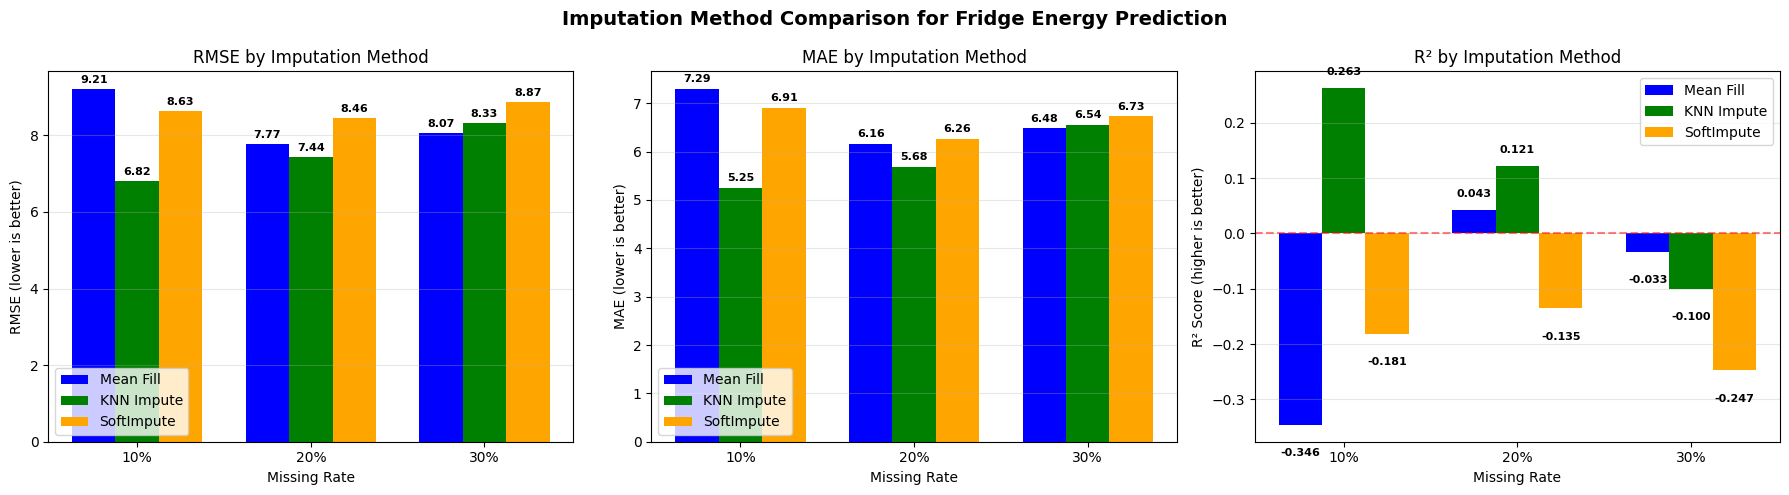

Chart saved to /content/imputation_comparison.png


In [ ]:
# Step 7: Visualize the results
# RMSE, MAE, and R²
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = {'Mean Fill': 'blue', 'KNN Impute': 'green', 'SoftImpute': 'orange'}
rates = ['10%', '20%', '30%']
x = np.arange(len(rates))
width = 0.25

# Chart 1: RMSE
ax1 = axes[0]
for i, method in enumerate(['Mean Fill', 'KNN Impute', 'SoftImpute']):
    vals = results_df[results_df['Method'] == method]['RMSE'].values
    bars = ax1.bar(x + i*width, vals, width, label=method, color=colors[method])
    for bar, val in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax1.set_xlabel('Missing Rate')
ax1.set_ylabel('RMSE (lower is better)')
ax1.set_title('RMSE by Imputation Method')
ax1.set_xticks(x + width)
ax1.set_xticklabels(rates)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Chart 2: MAE
ax2 = axes[1]
for i, method in enumerate(['Mean Fill', 'KNN Impute', 'SoftImpute']):
    vals = results_df[results_df['Method'] == method]['MAE'].values
    bars = ax2.bar(x + i*width, vals, width, label=method, color=colors[method])
    for bar, val in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax2.set_xlabel('Missing Rate')
ax2.set_ylabel('MAE (lower is better)')
ax2.set_title('MAE by Imputation Method')
ax2.set_xticks(x + width)
ax2.set_xticklabels(rates)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Chart 3: R² Score
ax3 = axes[2]
for i, method in enumerate(['Mean Fill', 'KNN Impute', 'SoftImpute']):
    vals = results_df[results_df['Method'] == method]['R²'].values
    bars = ax3.bar(x + i*width, vals, width, label=method, color=colors[method])
    for bar, val in zip(bars, vals):
        ax3.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.02 if val >= 0 else -0.06),
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax3.set_xlabel('Missing Rate')
ax3.set_ylabel('R² Score (higher is better)')
ax3.set_title('R² by Imputation Method')
ax3.set_xticks(x + width)
ax3.set_xticklabels(rates)
ax3.legend()
ax3.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax3.grid(axis='y', alpha=0.3)

plt.suptitle('Imputation Method Comparison for Fridge Energy Prediction',
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/imputation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to /content/imputation_comparison.png")

In [ ]:
# Step 8: Summary of findings
print()
print("  Project findings/Summary")
print()

print("""
  Dataset: IoT-Based Energy and Environmental Parameters
           in a Smart Building Infrastructure
  Source:  github.com/adel8641
  Task:    Predict fridge energy consumption (watts) from
           other appliance and room sensor readings
  Model:   Default Decision Tree (no tuning)

  Research question:
  Which data imputation strategy produces the best
  downstream predictions on sparse IoT sensor data?

  Answer: KNN Imputation outperformed both Mean Fill and
  SoftImpute at every missing rate tested.
""")

# Print the winning method at each rate
print("  Best method at each missing rate:")
print("  " + "-" * 50)
for rate in ['10%', '20%', '30%']:
    rate_results = results_df[results_df['Missing Rate'] == rate]
    best = rate_results.loc[rate_results['RMSE'].idxmin()]
    print(f"  {rate} missing → {best['Method']} wins (RMSE: {best['RMSE']}, R²: {best['R²']})")

print(f"""
  Key takeaways:
  1. KNN Imputation gave the best results across the board
     because it uses similar rows to estimate missing values,
     preserving relationships between sensors

  2. SoftImpute (matrix completion) came in last at every
     missing rate despite being the most complex method.
     More math does not always mean better results

  3. As missing rate increased from 10% to 30%, all methods
     got worse — but KNN degraded the slowest, showing it
     is the most robust to increasing data loss

  4. Mean Fill became competitive with KNN at 30% missing,
     suggesting that when data is very sparse, simple
     approaches can hold their own

  Tools used:
  - scikit-learn (KNNImputer, SimpleImputer, DecisionTreeRegressor)
  - fancyimpute (SoftImpute)
  - pandas, numpy, matplotlib
""")


  Project findings/Summary


  Dataset: IoT-Based Energy and Environmental Parameters
           in a Smart Building Infrastructure
  Source:  github.com/adel8641
  Task:    Predict fridge energy consumption (watts) from
           other appliance and room sensor readings
  Model:   Default Decision Tree (no tuning)

  Research question:
  Which data imputation strategy produces the best
  downstream predictions on sparse IoT sensor data?

  Answer: KNN Imputation outperformed both Mean Fill and
  SoftImpute at every missing rate tested.

  Best method at each missing rate:
  --------------------------------------------------
  10% missing → KNN Impute wins (RMSE: 6.8193, R²: 0.2625)
  20% missing → KNN Impute wins (RMSE: 7.4432, R²: 0.1214)
  30% missing → Mean Fill wins (RMSE: 8.07, R²: -0.0328)

  Key takeaways:
  1. KNN Imputation gave the best results across the board
     because it uses similar rows to estimate missing values,
     preserving relationships between sensors

  2.